In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("churn_cleaned_data.csv")

In [3]:
X=df.drop(columns=["Churn"])
Y=df["Churn"]

In [4]:
X.shape

(10000, 12)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2, 
    random_state=42, 
    stratify=Y  # مهم جداً لضمان توزيع الفئات المتوازن
)

In [6]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("\n--- Target Distribution in Train ---")
print(y_train.value_counts(normalize=True) * 100)
print("\n--- Target Distribution in Test ---")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (8000, 12)
X_test shape:  (2000, 12)

--- Target Distribution in Train ---
Churn
0    77.55
1    22.45
Name: proportion, dtype: float64

--- Target Distribution in Test ---
Churn
0    77.55
1    22.45
Name: proportion, dtype: float64


In [7]:
num_cols = ['TenureMonths', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [8]:
X_train_scaled.shape

(8000, 12)

In [9]:

W=np.zeros(X_train.shape[1])
W.shape
b=0




In [10]:
W.shape

(12,)

In [11]:
Y.shape

(10000,)

In [12]:
def linear_func(w,x,b):
    z=np.dot(x,w)+b
    return z


In [13]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    y_prob=(1)/(1+np.exp(-1*z))
    return y_prob


In [14]:
z=linear_func(w=W,x=X_train,b=b)
y_pro=sigmoid(z)

In [15]:

import numpy as np

def cost_func(Y, y_prob,w,lambda_=0.1):
   
    m = y_prob.shape[0]
    
    # 2. حماية الكود من قيم صفرية بداخل اللوغاريتم لتجنب خطأ NaN
    epsilon = 1e-15
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

    loss = -np.mean(Y * np.log(y_prob) + (1 - Y) * np.log(1 - y_prob))
    reg_cost = (lambda_ / (2 * m)) * np.sum(w**2)


    
    return loss + reg_cost



In [16]:
cost=cost_func(y_train,y_pro,W)
cost


np.float64(0.6931471805599454)

In [17]:
def compute_gradients(x,y,y_hat,w,lambda_=0.1):
    m=y.shape[0]
    gradients={}
    dj_dw=(1/m)*np.dot(x.T,(y_hat-y))+ (lambda_ / m) * w
    dj_db=(1/m)*np.sum(y_hat-y)
    gradients["dw"]=dj_dw
    gradients["db"]=dj_db
    return gradients




In [18]:
z=linear_func(W,X_train,b)
y_hat=sigmoid(z)
grads=compute_gradients(X_train,y_train,y_hat,W)
print(grads["dw"])

[1.09603125e+01 1.26988750e+01 1.60221606e+01 7.77040317e+02
 5.57177625e+02 1.85475000e+00 1.40687500e-01 1.12812500e-01
 5.29375000e-02 6.45625000e-02 6.68750000e-02 8.00000000e-02]


In [19]:
def optimize(max_iteration,cost_f,compute_grad,linear,activation,w,b,alpha,x,y):
    cost_history = []
    updated_parameter={}
    for i in range(max_iteration):
        z=linear(w,x,b)
        y_hat=activation(z)
        cost=cost_f(y,y_hat,w)
        cost_history.append(cost)
        grads=compute_grad(x,y,y_hat,w)
        w=w-alpha*grads["dw"]
        b=b-alpha*grads["db"]
        if i%100==0 or i == max_iteration - 1:
            print(f"iteration{i}: cost={cost}")
    updated_parameter["w"]=w
    updated_parameter["b"]=b
    return updated_parameter



In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# تقييس كامل المصفوفة X_train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
new_parameters=optimize(max_iteration=1000,cost_f=cost_func,compute_grad=compute_gradients,linear=linear_func,activation=sigmoid,w=W,b=b,alpha=0.1,x=X_train_scaled,y=y_train)

iteration0: cost=0.6931471805599454
iteration100: cost=0.4459510106628842
iteration200: cost=0.43350283815667595
iteration300: cost=0.4312455952201642
iteration400: cost=0.4305848640981362
iteration500: cost=0.4303034497562638
iteration600: cost=0.43014489779265863
iteration700: cost=0.4300398363501872
iteration800: cost=0.429964195599614
iteration900: cost=0.4299072701639452
iteration999: cost=0.4298636609783166


In [22]:
new_parameters["w"]

array([ 0.02975343, -0.78273205,  0.87078132, -0.10328942,  0.10304541,
       -0.00710809, -0.03034811,  0.0028559 ,  0.0151911 , -0.0236566 ,
       -0.03421568,  0.01826595])

In [23]:
new_parameters["b"]

np.float64(-1.6166332797435254)

In [24]:
def predict(x, w, b, threshold=0.26):
    # 1. Forward Pass لحساب Z والاحتمالات
    z = linear_func(w,x, b)
    y_prob = sigmoid(z)
    
    # 2. تحويل الاحتمال إلى 0 أو 1 بناءً على الـ threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    return y_pred, y_prob

# استخراج الأوزان المدربة من new_parameters
W_trained = new_parameters["w"]
b_trained = new_parameters["b"]

# التوقع على بيانات الاختبار X_test_scaled
y_pred_test, y_prob_test = predict(X_test_scaled, W_trained, b_trained)

# 1. حساب الـ Cost على test data
test_cost = cost_func(y_test, y_prob_test,W)
print(f"Test Cost: {test_cost:.4f}")

# 2. حساب الدقة Accuracy
accuracy = np.mean(y_pred_test == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Cost: 0.4325
Test Accuracy: 73.90%


In [25]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_test))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_test))

--- Confusion Matrix ---
[[1172  379]
 [ 143  306]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1551
           1       0.45      0.68      0.54       449

    accuracy                           0.74      2000
   macro avg       0.67      0.72      0.68      2000
weighted avg       0.79      0.74      0.76      2000



In [26]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. حساب الـ Precision والـ Recall لكل العتبات الممكنة
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# 2. حساب F1-score لكل عتبة
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 3. تحديد أقصى قيمة لـ F1-Score واستخراج العتبة المقابلة لها
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold for Best F1-Score: {best_threshold:.2f}")
print(f"Max F1-Score Achieved: {f1_scores[best_idx]:.2f}")

Optimal Threshold for Best F1-Score: 0.26
Max F1-Score Achieved: 0.54


## Random forest 

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. تحديد شبكة المعلمات للبحث عن أفضل توليفة
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],                # تقليل العمق لمنع الـ Overfitting
    'min_samples_split': [5, 10, 15],        # اشتراط عدد عينات أكبر للتقسيم
    'min_samples_leaf': [2, 4, 8],           # اشتراط عدد عينات أوراق أكبر
    'class_weight': ['balanced', 'balanced_subsample']
}

# 2. إنشاء الـ GridSearchCV مع 5-Fold Cross-Validation
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',                         # التركيز على F1-Score للفئة المستهدفة
    n_jobs=-1
)

# 3. التدريب لاستخراج الموديل الأمثل
grid_search.fit(X_train, y_train)

# أفضل موديل
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 200}


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. إنشاء الموديل وتدريبه
rf_model = RandomForestClassifier(
    n_estimators= 200,         # عدد الأشجار
    max_depth=6,              # للحد من الـ Overfitting
    class_weight='balanced_subsample',   # لموازنة الفئات تلقائياً
    min_samples_leaf=8,
    min_samples_split=5,
    random_state=42
)

# ملاحظة: Random Forest لا تحتاج لـ X_test_scaled، لكن يمكنك استخدام البيانات المقيسة أو الأصلية
rf_model.fit(X_train, y_train)

# 2. التوقع
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. طباعة التقرير
print("=== Random Forest Report ===")
print(confusion_matrix(y_test, y_pred_rf))
print("\n", classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest Report ===
[[1138  413]
 [ 138  311]]

               precision    recall  f1-score   support

           0       0.89      0.73      0.81      1551
           1       0.43      0.69      0.53       449

    accuracy                           0.72      2000
   macro avg       0.66      0.71      0.67      2000
weighted avg       0.79      0.72      0.74      2000

ROC-AUC Score: 0.7803


In [29]:
from sklearn.metrics import accuracy_score, log_loss, classification_report

# حساب الأداء الجديد
train_acc = accuracy_score(y_train, best_rf.predict(X_train))
test_acc = accuracy_score(y_test, best_rf.predict(X_test))

train_loss = log_loss(y_train, best_rf.predict_proba(X_train))
test_loss = log_loss(y_test, best_rf.predict_proba(X_test))

print(f"New Train Accuracy: {train_acc * 100:.2f}% | Train Loss: {train_loss:.4f}")
print(f"New Test Accuracy:  {test_acc * 100:.2f}% | Test Loss:  {test_loss:.4f}\n")

# تقرير التصنيف النهائي
print(classification_report(y_test, best_rf.predict(X_test)))

New Train Accuracy: 75.08% | Train Loss: 0.5214
New Test Accuracy:  72.45% | Test Loss:  0.5579

              precision    recall  f1-score   support

           0       0.89      0.73      0.81      1551
           1       0.43      0.69      0.53       449

    accuracy                           0.72      2000
   macro avg       0.66      0.71      0.67      2000
weighted avg       0.79      0.72      0.74      2000



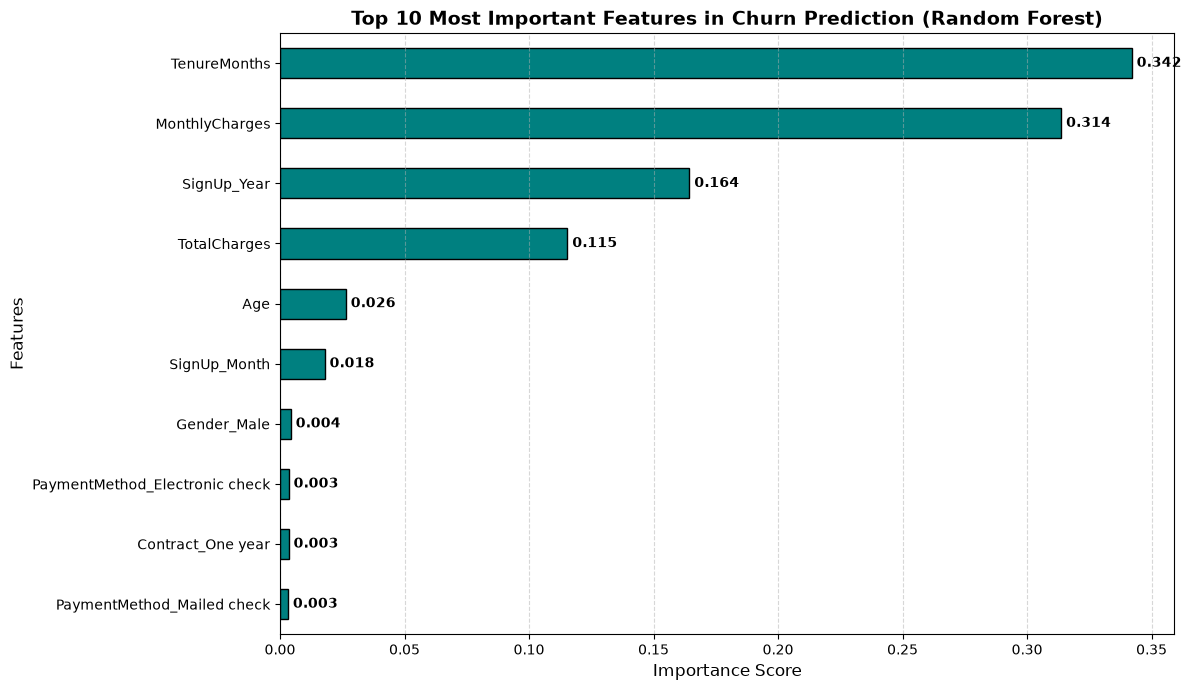

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. استخراج أهمية الميزات من نموذج Random Forest النهائي
importances = rf_model.feature_importances_

# 2. جلب أسماء الميزات (تأكد أن X_train يحتوي على الميزات الجديدة المضافة)
# إذا أضفت ميزات مثل Is_New_Customer أو Risk_Score، ستظهر هنا تلقائياً
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]

# 3. إنشاء Series لترتيب الميزات تنازلياً حسب الأهمية
feature_imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 4. رسم أعلى 10 ميزات (أو كل الميزات إذا كانت أقل من 10)
# زيادة figsize لضمان وضوح أسماء الميزات الطويلة
plt.figure(figsize=(12, 7))
feature_imp_df.head(10).plot(kind='barh', color='teal', edgecolor='black')

# 5. التظبيط والتحسينات البصرية
plt.title('Top 10 Most Important Features in Churn Prediction (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# قلب المحور الصادي لتظهر أهم ميزة في الأعلى
plt.gca().invert_yaxis()

# إضافة شبكة خلفية لتسهيل قراءة القيم
plt.grid(axis='x', linestyle='--', alpha=0.5)

# إضافة قيم الأهمية كنصوص على كل بار (Text Annotations)
for index, value in enumerate(feature_imp_df.head(10)):
    plt.text(value, index, f' {value:.3f}', va='center', fontweight='bold')

plt.tight_layout() # لضمان عدم قطع أسماء الميزات أو العناوين
plt.show()

## Some feature Engineering 

In [31]:
# تقسيم مدة البقاء إلى فئات (مثل: جدد، متوسطين، قدامى)
X_train['Is_New_Customer'] = (X_train['TenureMonths'] <= 12).astype(int)
X_test['Is_New_Customer'] = (X_test['TenureMonths'] <= 12).astype(int)

In [32]:
X_train['Charges_Per_Age'] = X_train['MonthlyCharges'] / (X_train['Age'] + 1)
X_test['Charges_Per_Age'] = X_test['MonthlyCharges'] / (X_test['Age'] + 1)

In [33]:
X_train['Risk_Score'] = X_train['MonthlyCharges'] / (X_train['TenureMonths'] + 1)
X_test['Risk_Score'] = X_test['MonthlyCharges'] / (X_test['TenureMonths'] + 1)

In [34]:
X_train.shape

(8000, 15)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. تحديد شبكة المعلمات للبحث عن أفضل توليفة
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],                # تقليل العمق لمنع الـ Overfitting
    'min_samples_split': [5, 10, 15],        # اشتراط عدد عينات أكبر للتقسيم
    'min_samples_leaf': [2, 4, 8],           # اشتراط عدد عينات أوراق أكبر
    'class_weight': ['balanced', 'balanced_subsample']
}

# 2. إنشاء الـ GridSearchCV مع 5-Fold Cross-Validation
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',                         # التركيز على F1-Score للفئة المستهدفة
    n_jobs=-1
)

# 3. التدريب لاستخراج الموديل الأمثل
grid_search.fit(X_train, y_train)

# أفضل موديل
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 100}


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. إنشاء الموديل وتدريبه
rf_model = RandomForestClassifier(
    n_estimators= 100,         # عدد الأشجار
    max_depth=6,              # للحد من الـ Overfitting
    class_weight='balanced_subsample',   # لموازنة الفئات تلقائياً
    min_samples_leaf=8,
    min_samples_split=5,
    random_state=42
)

# ملاحظة: Random Forest لا تحتاج لـ X_test_scaled، لكن يمكنك استخدام البيانات المقيسة أو الأصلية
rf_model.fit(X_train, y_train)

# 2. التوقع
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
NEW_THRESHOLD = 0.5252
y_pred_new = (y_prob_rf >= NEW_THRESHOLD).astype(int)

# 3. طباعة التقرير
print("=== Random Forest Report ===")
print(confusion_matrix(y_test, y_pred_new))
print("\n", classification_report(y_test, y_pred_new))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Random Forest Report ===
[[1157  394]
 [ 140  309]]

               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1551
           1       0.44      0.69      0.54       449

    accuracy                           0.73      2000
   macro avg       0.67      0.72      0.67      2000
weighted avg       0.79      0.73      0.75      2000

ROC-AUC Score: 0.7853


In [45]:
from sklearn.metrics import precision_recall_curve

# 1. حساب جميع قيم Precision و Recall عند كل Threshold ممكن
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 2. حساب الـ F1-Score لكل Threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 3. معرفة أعلى F1-Score والـ Threshold المقابل له
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"🎯 Optimal Threshold (Max F1): {best_thresh:.4f}")
print(f"Precision at Best Threshold:  {precisions[best_idx]:.4f}")
print(f"Recall at Best Threshold:     {recalls[best_idx]:.4f}")
print(f"Max F1-Score:                 {f1_scores[best_idx]:.4f}")

🎯 Optimal Threshold (Max F1): 0.5252
Precision at Best Threshold:  0.4403
Recall at Best Threshold:     0.6904
Max F1-Score:                 0.5377


In [49]:
from sklearn.metrics import accuracy_score, log_loss, classification_report

# حساب الأداء الجديد
train_acc = accuracy_score(y_train, best_rf.predict(X_train))
test_acc = accuracy_score(y_test, best_rf.predict(X_test))

train_loss = log_loss(y_train, best_rf.predict_proba(X_train))
test_loss = log_loss(y_test, best_rf.predict_proba(X_test))
print(confusion_matrix(y_test, best_rf.predict(X_test)))
print(f"New Train Accuracy: {train_acc * 100:.2f}% | Train Loss: {train_loss:.4f}")
print(f"New Test Accuracy:  {test_acc * 100:.2f}% | Test Loss:  {test_loss:.4f}\n")

# تقرير التصنيف النهائي
print(classification_report(y_test, best_rf.predict(X_test)))

[[1110  441]
 [ 124  325]]
New Train Accuracy: 74.49% | Train Loss: 0.5145
New Test Accuracy:  71.75% | Test Loss:  0.5519

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1551
           1       0.42      0.72      0.53       449

    accuracy                           0.72      2000
   macro avg       0.66      0.72      0.67      2000
weighted avg       0.79      0.72      0.74      2000



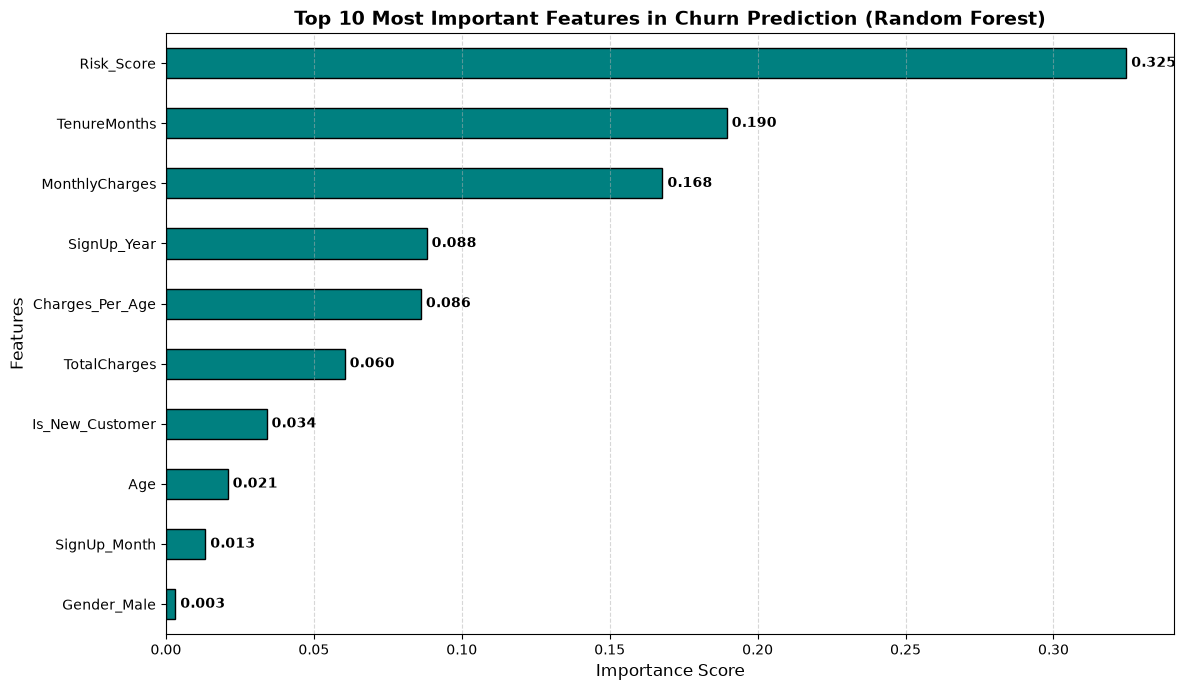

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. استخراج أهمية الميزات من نموذج Random Forest النهائي
importances = rf_model.feature_importances_

# 2. جلب أسماء الميزات (تأكد أن X_train يحتوي على الميزات الجديدة المضافة)
# إذا أضفت ميزات مثل Is_New_Customer أو Risk_Score، ستظهر هنا تلقائياً
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]

# 3. إنشاء Series لترتيب الميزات تنازلياً حسب الأهمية
feature_imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 4. رسم أعلى 10 ميزات (أو كل الميزات إذا كانت أقل من 10)
# زيادة figsize لضمان وضوح أسماء الميزات الطويلة
plt.figure(figsize=(12, 7))
feature_imp_df.head(10).plot(kind='barh', color='teal', edgecolor='black')

# 5. التظبيط والتحسينات البصرية
plt.title('Top 10 Most Important Features in Churn Prediction (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# قلب المحور الصادي لتظهر أهم ميزة في الأعلى
plt.gca().invert_yaxis()

# إضافة شبكة خلفية لتسهيل قراءة القيم
plt.grid(axis='x', linestyle='--', alpha=0.5)

# إضافة قيم الأهمية كنصوص على كل بار (Text Annotations)
for index, value in enumerate(feature_imp_df.head(10)):
    plt.text(value, index, f' {value:.3f}', va='center', fontweight='bold')

plt.tight_layout() # لضمان عدم قطع أسماء الميزات أو العناوين
plt.show()

In [41]:
X_train["Risk_Score"]

7955     6.209412
1219     5.181818
7065     0.649722
4346     5.081739
1652     1.645745
          ...    
333      2.902105
7740     0.515185
2319     2.220465
8192    16.718571
2058     3.300000
Name: Risk_Score, Length: 8000, dtype: float64

In [42]:
X_train["Charges_Per_Age"]

7955    2.852973
1219    1.390244
7065    0.974583
4346    1.885161
1652    1.886585
          ...   
333     3.063333
7740    0.993571
2319    3.292414
8192    2.854390
2058    2.253659
Name: Charges_Per_Age, Length: 8000, dtype: float64

## XGBOOST


In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 0.8/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 0.8/101.7 MB 882.6 kB/s eta 0:01:55
   ---------------------------------------- 1.0/101.7 MB 867.1 kB/s eta 0:01:57
    --------------------------------------- 1.3/101.7 MB 860.2 kB/s eta 0:01:57
    --------------------------------------- 1.3/101.7 MB 860.2 kB/s eta 0:01:57
    --------------------------------------- 1.6/101.7 MB 864.6 kB/s eta 0:01:56
    --------------------------------------- 1.8/101.7 MB 867.5 kB/s eta 0:01:56
    --------------------------------------- 1.8/101.7 MB 867.5 kB/s eta 0:01

In [49]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. الحصول على الاحتمالات للفئة 1
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 2. حساب منحنى Precision-Recall للبحث عن أفضل Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

# 3. التوقع بالعتبة المحسنة
y_pred_opt_xgb = (y_probs_xgb >= best_thresh).astype(int)

print(f"Optimal Threshold for XGBoost: {best_thresh:.4f}\n")
print(confusion_matrix(y_test, y_pred_opt_xgb))
print("\n", classification_report(y_test, y_pred_opt_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs_xgb):.4f}")

Optimal Threshold for XGBoost: 0.5160

[[1134  417]
 [ 131  318]]

               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1551
           1       0.43      0.71      0.54       449

    accuracy                           0.73      2000
   macro avg       0.66      0.72      0.67      2000
weighted avg       0.79      0.73      0.75      2000

ROC-AUC Score: 0.7760


In [48]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. حساب وزن الفئة المستهدفة لمعالجة الـ Imbalance تلقائياً
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 2. إنشاء وتدريب الموديل
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,                # عمق بسيط لمنع الـ Overfitting
    learning_rate=0.05,         # معدل تعلم هادئ للاستقرار
    scale_pos_weight=scale_weight, # موازنة الفئات تلقائياً
    subsample=0.8,              # أخذ 80% من البيانات لكل شجرة
    colsample_bytree=0.8,       # أخذ 80% من الميزات لكل شجرة
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# 3. التوقعات
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 4. طباعة التقرير
print("=== XGBoost Report ===")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n", classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

=== XGBoost Report ===
[[1107  444]
 [ 128  321]]

               precision    recall  f1-score   support

           0       0.90      0.71      0.79      1551
           1       0.42      0.71      0.53       449

    accuracy                           0.71      2000
   macro avg       0.66      0.71      0.66      2000
weighted avg       0.79      0.71      0.74      2000

ROC-AUC Score: 0.7760


## Saving Final model

In [43]:
import joblib

# 1. تجميع الـ Payload الخاص بالنموذج النهائي
final_model_payload = {
    'model': rf_model, 
    'feature_names': list(X_train.columns),
    'model_performance': {
        'recall': 0.72,
        'f1_score': 0.53,
        'roc_auc': 0.7803
    }
}

# 2. الحفظ المباشر داخل فولدر final باستخدام المسار الكامل (r"...")
save_path = r'D:\Deep learning\final\random_forest_churn_model.pkl'
joblib.dump(final_model_payload, save_path)

print(f"تم حفظ الملف بنجاح داخل: {save_path}")

تم حفظ الملف بنجاح داخل: D:\Deep learning\final\random_forest_churn_model.pkl
